In [1]:
## Imports

import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[1])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import TotalVariationRecon, L1WaveletRecon
from scipy.io import savemat
import twixtools
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.signal import butter,filtfilt


## My files
from ksp_plot_helpers import plot_ksp_data_multichannel, find_and_plot_acquired_region
from raw_data_utils import get_kspace_data, get_TR
from resp_signal_functions import resp_signal_all_slices, resp_signal_single_slice, resp_signal_center_sample_single_slice
from resp_signal_plot_functions import *
import gating_functions
from pca_helper import pca_resp_signal
from save_data_helpers import *

## Data loading

Software version: VD/VE (!?)

Scan  0


100%|██████████| 15.9G/15.9G [00:13<00:00, 1.30GB/s]


Full number of partitions = 72
ksp_data.shape = (15, 58, 2002, 256)
Average value, slices vs samples per gate = 3.577272582333535e-05
Average value, readouts vs spokes per gate = 3.644393291324377e-05
Average value, slices vs center sample per gate = 0.00014447004650719464


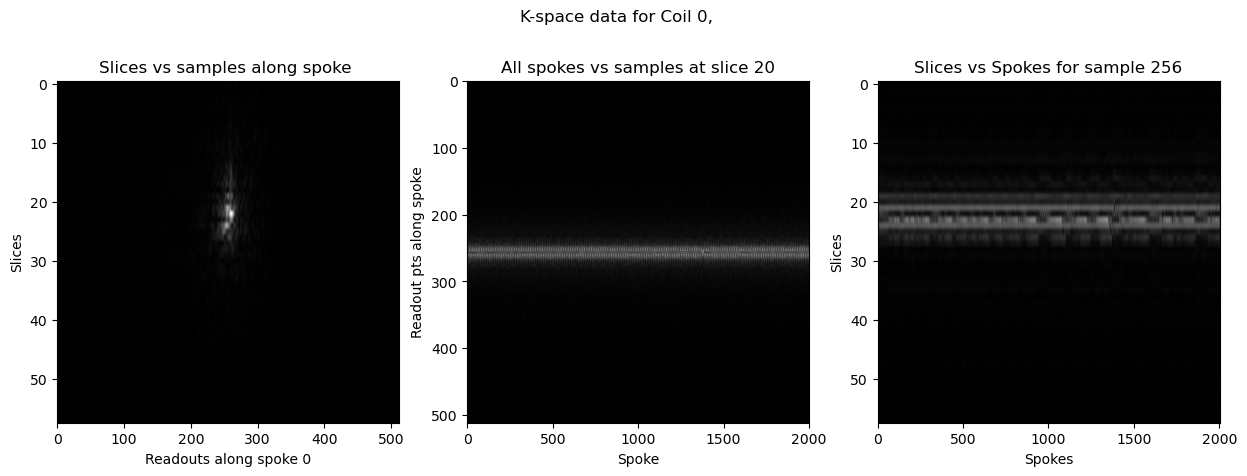

In [2]:
data_file_pt2 = '/data/lilianae/NaF_Patient2/anon_meas_MID00082_FID64646_Tho_fl3d_star_vibe_991_nav_tj_2000sp_AllCoils_SOS_2.dat'
multi_twix, mapped, _ = get_kspace_data(data_file_pt2)

ksp_512 = read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
fig, axs = plot_ksp_data_multichannel(ksp_data=ksp_512, coil_idx=0, center_slice=20, center_sample=256)

Look at signal intensity distribution

Signal energy per slice: [0.00034923 0.00038977 0.0004448  0.00050871 0.00057384 0.00063816
 0.00071494 0.00082209 0.00094068 0.00107306 0.00128525 0.00144249
 0.00183981 0.00230637 0.00360145 0.00507774 0.00634191 0.01135587
 0.01433469 0.02268788 0.03864673 0.06843735 0.06193767 0.05600877
 0.03791705 0.0243057  0.01145057 0.00686557 0.00434409 0.00334172
 0.00260356 0.00208694 0.00176929 0.00151931 0.0012426  0.00109912
 0.00097157 0.00082282 0.00075216 0.00069218 0.00064961 0.00057879
 0.00054884 0.00051587 0.00045052 0.00043207 0.00039868 0.00037606
 0.00034749 0.00032715 0.00030075 0.00027867 0.00027971 0.00025479
 0.0002434  0.00022852 0.00021765 0.00020923]
Threshold: 0.0006843734532594681
Acquired region detected: slices 6 to 39
Width of center region: 33


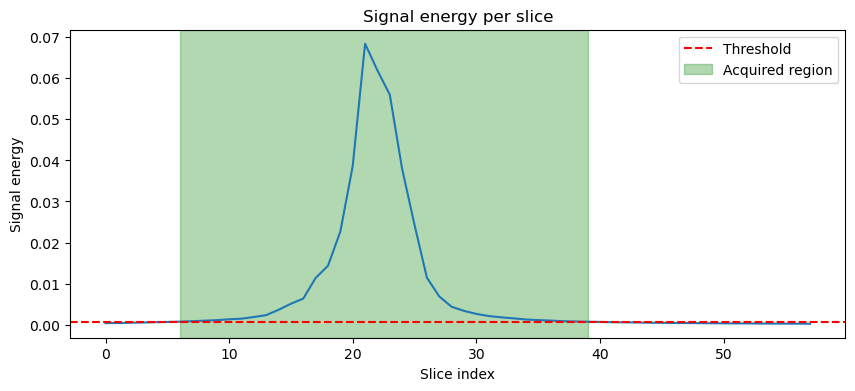

In [3]:
acquired_start, acquired_end = find_and_plot_acquired_region(ksp_512)

Extract TR from header

In [4]:
TR = get_TR(mapped)

TR from data: 0.006 sec


Play with start and end samples for signal generation

In [5]:
start_sample_idx = 250
end_sample_idx = 260

### NEW FUNCTION for respiratory extraction

In [6]:
from filters import butter_lowpass_filter, butter_bandpass_filter

def resp_signal_center_sample_center_slice(ksp_data, TR, cutoff, center_slice=20, 
                                          sample_idx=256, filter_type='bandpass', 
                                          order=2, verbose=True):
    """
    Extract respiratory signal using central k-space sample from a single central slice.
    This gives an effective TR = TR * num_slices since we sample once per full volume.
    
    Parameters
    ----------
    ksp_data : ndarray
        K-space data of shape (ncoils, nslices, nspokes, nsamples)
    TR : float
        Base TR (time per spoke) in seconds
    cutoff : list or tuple
        [low_freq, high_freq] for bandpass filter in Hz
    center_slice : int
        Which slice to use (default 20 for center partition)
    sample_idx : int
        Which k-space sample to use (default 256 for center)
    filter_type : str
        'bandpass' or 'lowpass'
    order : int
        Butterworth filter order
    verbose : bool
        Print diagnostic information
        
    Returns
    -------
    raw_signal_all : ndarray
        Shape (ncoils, timepoints), raw signal from center slice only
    filt_signal_all : ndarray
        Shape (ncoils, timepoints), filtered signal from center slice only
    TR_eff : float
        Effective TR in seconds (TR * num_slices)
    fs_eff : float
        Effective sampling frequency in Hz
    """
    num_coils, num_slices, num_spokes, num_samples = ksp_data.shape
    
    # Effective TR: only sample the center slice once per volume?
    TR_eff = TR * num_slices
    fs_eff = 1 / TR_eff  # Effective sampling frequency in Hz
    
    # Number of temporal samples = number of spokes (sampling center slice once per spoke cycle)
    n_temporal_samples = num_spokes
    
    # time scale in seconds
    time_scale_s = np.arange(n_temporal_samples) * TR_eff
    
    raw_signal_all = []
    filt_signal_all = []
    
    for c in range(num_coils):
        # Extract signal from center slice, center sample, all spokes
        # Shape: (nspokes,)
        signal = np.mean(np.abs(ksp_data[c, center_slice, :, 250:260]), axis=-1)
        
        raw_signal_all.append(signal)
        
        # Apply bandpass filter
        if filter_type == 'bandpass':
            filtered_signal = butter_bandpass_filter(
                signal, 
                start_cutoff_hz=cutoff[0], 
                end_cutoff_hz=cutoff[1], 
                fs_hz=fs_eff, 
                order=order
            )
        else:  # lowpass
            filtered_signal = butter_lowpass_filter(
                signal, 
                cutoff[0], 
                fs_eff, 
                order=order
            )
        
        filt_signal_all.append(filtered_signal)
    
    # Stack into arrays
    raw_signal_all = np.stack(raw_signal_all, axis=0)  # (coils, timepoints)
    filt_signal_all = np.stack(filt_signal_all, axis=0)  # (coils, timepoints)
    
    if verbose:
        print(f"Base TR (per spoke): {TR:.6f} s")
        print(f"Number of slices: {num_slices}")
        print(f"Effective TR (per volume): {TR_eff:.6f} s ({TR_eff*1000:.3f} ms)")
        print(f"Effective sampling frequency: {fs_eff:.3f} Hz")
        print(f"Total acquisition time: {time_scale_s[-1]:.2f} s")
        print(f"Number of temporal samples: {n_temporal_samples}")
        print(f"Bandpass filter: {cutoff[0]:.3f} - {cutoff[1]:.3f} Hz")
        print(f"Expected respiratory rate: {cutoff[0]*60:.1f} - {cutoff[1]*60:.1f} breaths/min")
        print(f"raw_signal_all.shape: {raw_signal_all.shape}")
        print(f"filt_signal_all.shape: {filt_signal_all.shape}")
    
    return raw_signal_all, filt_signal_all, TR_eff, fs_eff

In [7]:
# from filters import butter_lowpass_filter, butter_bandpass_filter

# ## OLD WRONG

# def resp_signal_center_sample_center_slice(ksp_data, TR, cutoff, center_slice, verbose=True):
#     """
#     Extract respiratory signal using only centermost k-space sample (and center-most partition)

#     Inputs
#     ---------------------------
#     ksp_data : ndarray
#         K-space data of shape (ncoils, nslices, nspokes, nsamples)
#     TR : float
#         TR from data    
#     cutoff : float
#         Cutoff frequency for Butterworth filter   
#     center_slice :: int
#         Partition to use for k-space sample extraction (default uses center)

#     Outputs
#     ---------------------------
#     raw_signal_all : ndarray
#         Shape (ncoils, timepoints), raw resp signal for all coils
#     filt_signal_all : ndarray
#         Shape (ncoils, timepoints), filtered resp signal for all coils
    
    
#     """
#     num_coils, num_slices, num_spokes, num_samples = ksp_data.shape

        
#     # Calculate center slice index
#     if center_slice is None:
#         center_slice = num_slices // 2
    

#     # Now we only have num_spokes temporal samples (not num_spokes * num_slices)
#     new_num_samples = num_spokes  # reduced temporal samples
    
#     # Effective sampling frequency - now slower by factor of num_slices
#     fs_effective = 1/(TR * num_slices)  # skip (num_slices-1) TRs between samples
    
#     # Now each sample is separated by (TR * num_slices)
#     TR_effective = TR * num_slices
#     full_time_scale_s = np.arange(new_num_samples) * TR_effective

#     raw_signal_all = []
#     filt_signal_all= []
#     for c in range(num_coils):
#         # Extract only center slice: shape (num_spokes,) after averaging center samples
#         signal = np.abs(ksp_data[c, :, :, num_samples//2])
#         signal = signal.T.flatten()
#         raw_signal_all.append(signal)
#         filtered_signal = butter_bandpass_filter(signal, start_cutoff_hz=cutoff[0], end_cutoff_hz=cutoff[1], fs_hz=fs_effective, order=2)
#         # filtered_signal = butter_lowpass_filter(signal, cutoff_hz=cutoff, fs_hz=fs_effective, order=2)
#         filt_signal_all.append(filtered_signal)
    
    
#     filt_signal_all= np.stack(filt_signal_all, axis=0)  # shape: (coils, time points)
#     raw_signal_all = np.stack(raw_signal_all, axis=0)

#     if verbose:
#         print(f"\nUsing center slice: {center_slice} out of {num_slices} slices")
#         print(f"\nEffective sampling frequency (Hz): {fs_effective:.3f}")
#         print(f"\nOriginal sampling frequency would have been: {1/TR:.3f} Hz")
#         print(f'\nFull timescale goes to {full_time_scale_s[-1]:.1f} seconds')
#         print(f'\nTime between respiratory samples: {TR_effective:.3f} seconds')
#         print(f"filt_signal_all.shape: {filt_signal_all.shape}")
#         print(f"raw_signal_all.shape: {raw_signal_all.shape}")


    
#     return raw_signal_all, filt_signal_all, TR_effective, fs_effective # return the effective TR

In [8]:
# from filters import butter_lowpass_filter, butter_bandpass_filter

# def resp_signal_all_slices_center_sample(ksp_data, TR, cutoff_hz, sample_idx, 
#                            filter_type='lowpass', order=2, verbose=True):
#     """
#     Extract respiratory signal using central k-space samples across all slices

#     Inputs
#     ---------------------------
#     ksp_data : ndarray
#         K-space data of shape (ncoils, nslices, nspokes, nsamples)
#     TR : float
#         TR from data  
#     cutoff_hz : float
#         Cutoff frequency for Butterworth filter   
#     start_sample_idx : int
#         Start index for central k-space samples (default 120)
#     end_sample_idx : int
#         End index for central k-space samples (default 140)
#     filter_type: str, (Optional)
#         Options = "lowpass", "bandpass", default="lowpass"
#     order : int, (optional)
#         Order for Butterworth filter
#     verbose: bool
#         Print output shapes if true 

#     Outputs
#     ---------------------------
#     raw_signal_all : ndarray
#         Shape (ncoils, timepoints), raw resp signal for all coils
#     filt_signal_all : ndarray
#         Shape (ncoils, timepoints), filtered resp signal for all coils
    
    
#     """
#     num_coils, num_slices, num_spokes, num_samples = ksp_data.shape

#     n_samples = num_spokes * num_slices  # total time points/temporal samples

#     # Sampling frequency in Hz
#     fs = 1/(TR)

#     # Build full time scale in SECONDS
#     full_time_scale_s = np.arange(n_samples) * TR  # time in s

#     raw_signal_all = []
#     filt_signal_all = []
#     for c in range(num_coils):
#         signal = np.abs(ksp_data[c, :, :,sample_idx])
#         signal = signal.T.flatten()  # flatten to 1D (time points)
#         raw_signal_all.append(signal)
#         # filtered_signal = butter_lowpass_filter(signal, cutoff_hz, fs, order=order)
#         filtered_signal = butter_bandpass_filter(signal, start_cutoff_hz=cutoff_hz[0], end_cutoff_hz=cutoff_hz[1], fs_hz=fs, order=order)
#         filt_signal_all.append(filtered_signal)

#     filt_signal_all = np.stack(filt_signal_all, axis=0)  # shape: (coils, time points)
#     raw_signal_all = np.stack(raw_signal_all, axis=0)  # shape: (coils, time points)

#     if verbose: 
#         print(f"Sampling frequency (Hz): {fs:.3f}")
#         print(f'full timescale goes to {full_time_scale_s[-1]} seconds')
#         print(f"filt_signal_all.shape: {filt_signal_all.shape}")
#         print(f"raw_signal_all.shape: {raw_signal_all.shape}")


#     return raw_signal_all, filt_signal_all

### Extract respiratory signal

In [9]:

print(f"\nUse center sample + center slice for signal: ")
print("="*60)

raw_signal_center_sample, filt_center_sample, TR_eff, fs_eff = resp_signal_center_sample_center_slice(ksp_512, 
                                                                                      TR=TR,
                                                                                      cutoff=[0.2, 0.33])


Use center sample + center slice for signal: 
Base TR (per spoke): 0.006000 s
Number of slices: 58
Effective TR (per volume): 0.348000 s (348.000 ms)
Effective sampling frequency: 2.874 Hz
Total acquisition time: 696.35 s
Number of temporal samples: 2002
Bandpass filter: 0.200 - 0.330 Hz
Expected respiratory rate: 12.0 - 19.8 breaths/min
raw_signal_all.shape: (15, 2002)
filt_signal_all.shape: (15, 2002)


### Plot raw signal

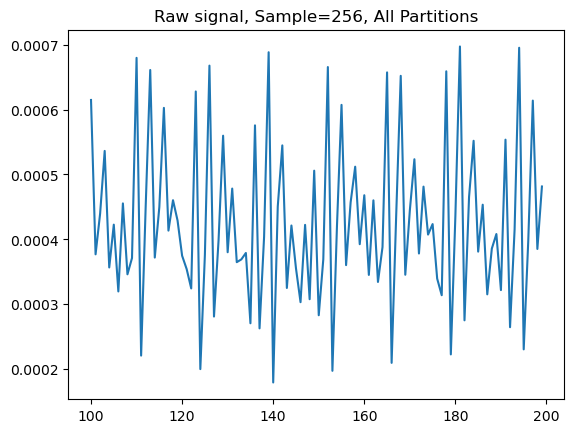

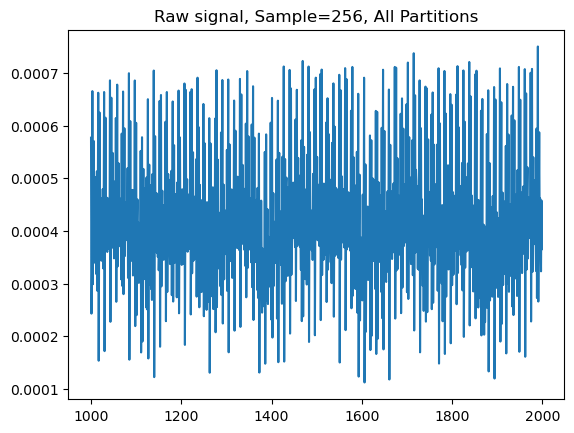

In [10]:
def plot_raw_signal_only(signal, coil_idx, start_idx, end_idx, title=""):
    fig, axs = plt.subplots()
    x_axis = np.arange(start_idx, end_idx)
    axs.plot(x_axis, signal[coil_idx][start_idx:end_idx])
    axs.set_title(f'{title}')
    plt.show()

    
start_idx = 100
end_idx=200
plot_raw_signal_only(raw_signal_center_sample, coil_idx=8,
                     start_idx=start_idx, end_idx=end_idx, title="Raw signal, Sample=256, All Partitions")

start_idx = 1000
end_idx=2000
plot_raw_signal_only(raw_signal_center_sample, coil_idx=8,
                     start_idx=start_idx, end_idx=end_idx, title="Raw signal, Sample=256, All Partitions")


### Plot frequency spectrum

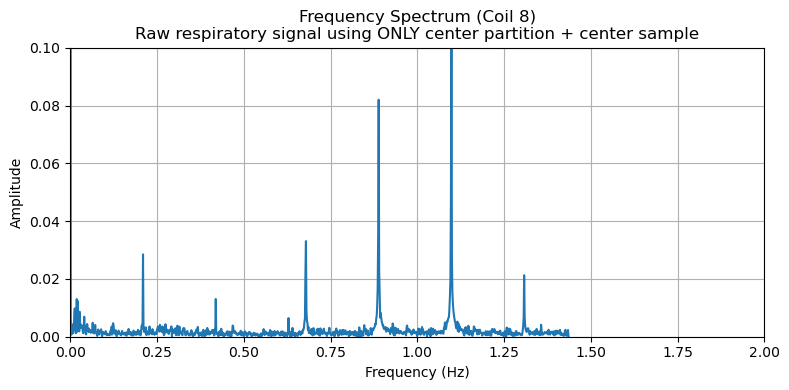

In [11]:
def plot_freq_spectrum(signal_coils, coil_idx, TR, fmax=2, amp_limit=None, title_info=""):
    """
    Plot the frequency spectrum (magnitude of FFT) for a given coil signal.

    Parameters
    ----------
    signal_coils : array-like
        Array of signals from different coils, shape (num_coils, num_samples)
    coil_idx : int
        Index of the coil to analyze
    TR : float
        Sampling interval (s)
    fmax : float, optional
        Maximum frequency (Hz) to display (default 2 Hz)
    amp_limit: float, optional
        Set y-axis limit to better zoom in
    title_info : str, optional
        Title info for plot
    """
    fs = 1 / TR
    signal = signal_coils[coil_idx]
    n = len(signal)

    # Compute FFT and frequencies
    fft_result = np.fft.fft(signal)
    freq = np.fft.fftfreq(n, d=TR)

    # Use only positive frequencies
    pos_mask = freq >= 0
    freq = freq[pos_mask]
    fft_result = np.abs(fft_result[pos_mask])

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(freq, fft_result)
    plt.xlim(0, fmax)
    if amp_limit is not None:
            plt.ylim(0, amp_limit)
    plt.title(f'Frequency Spectrum (Coil {coil_idx})' f'\n{title_info}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

coil_idx = 8

plot_freq_spectrum(raw_signal_center_sample, coil_idx=coil_idx, TR=TR_eff, fmax=2, 
                   amp_limit=0.1, title_info="Raw respiratory signal using ONLY center partition + center sample")

### Plot raw and unfiltered signal

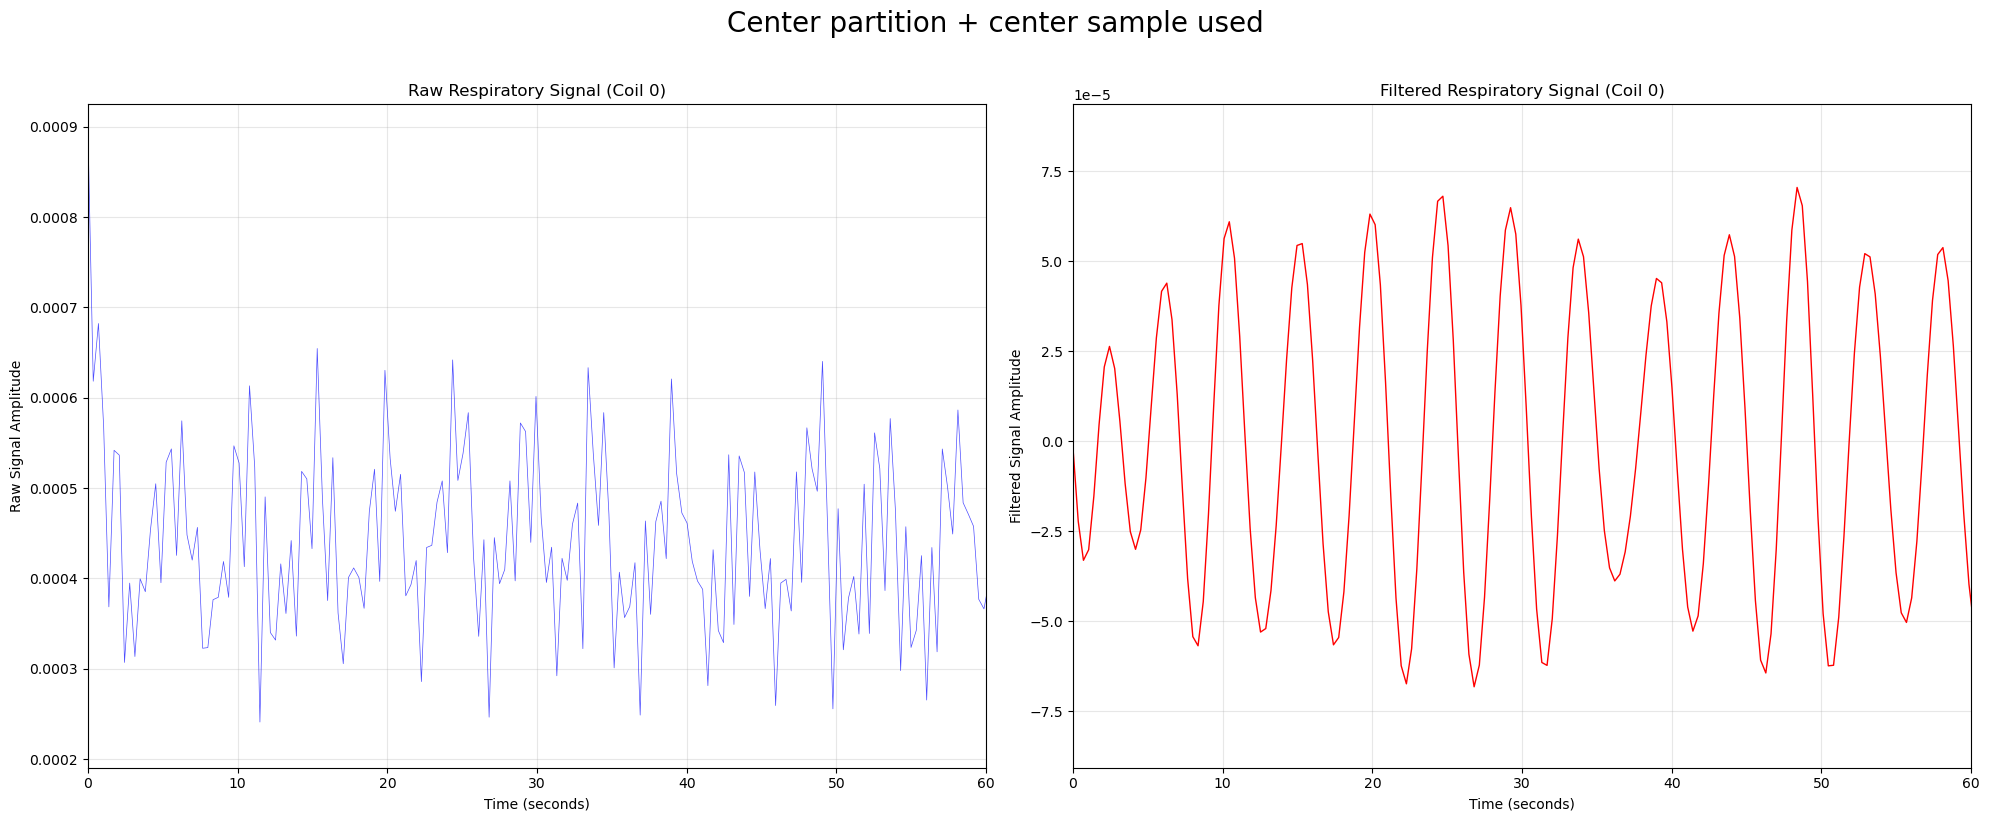

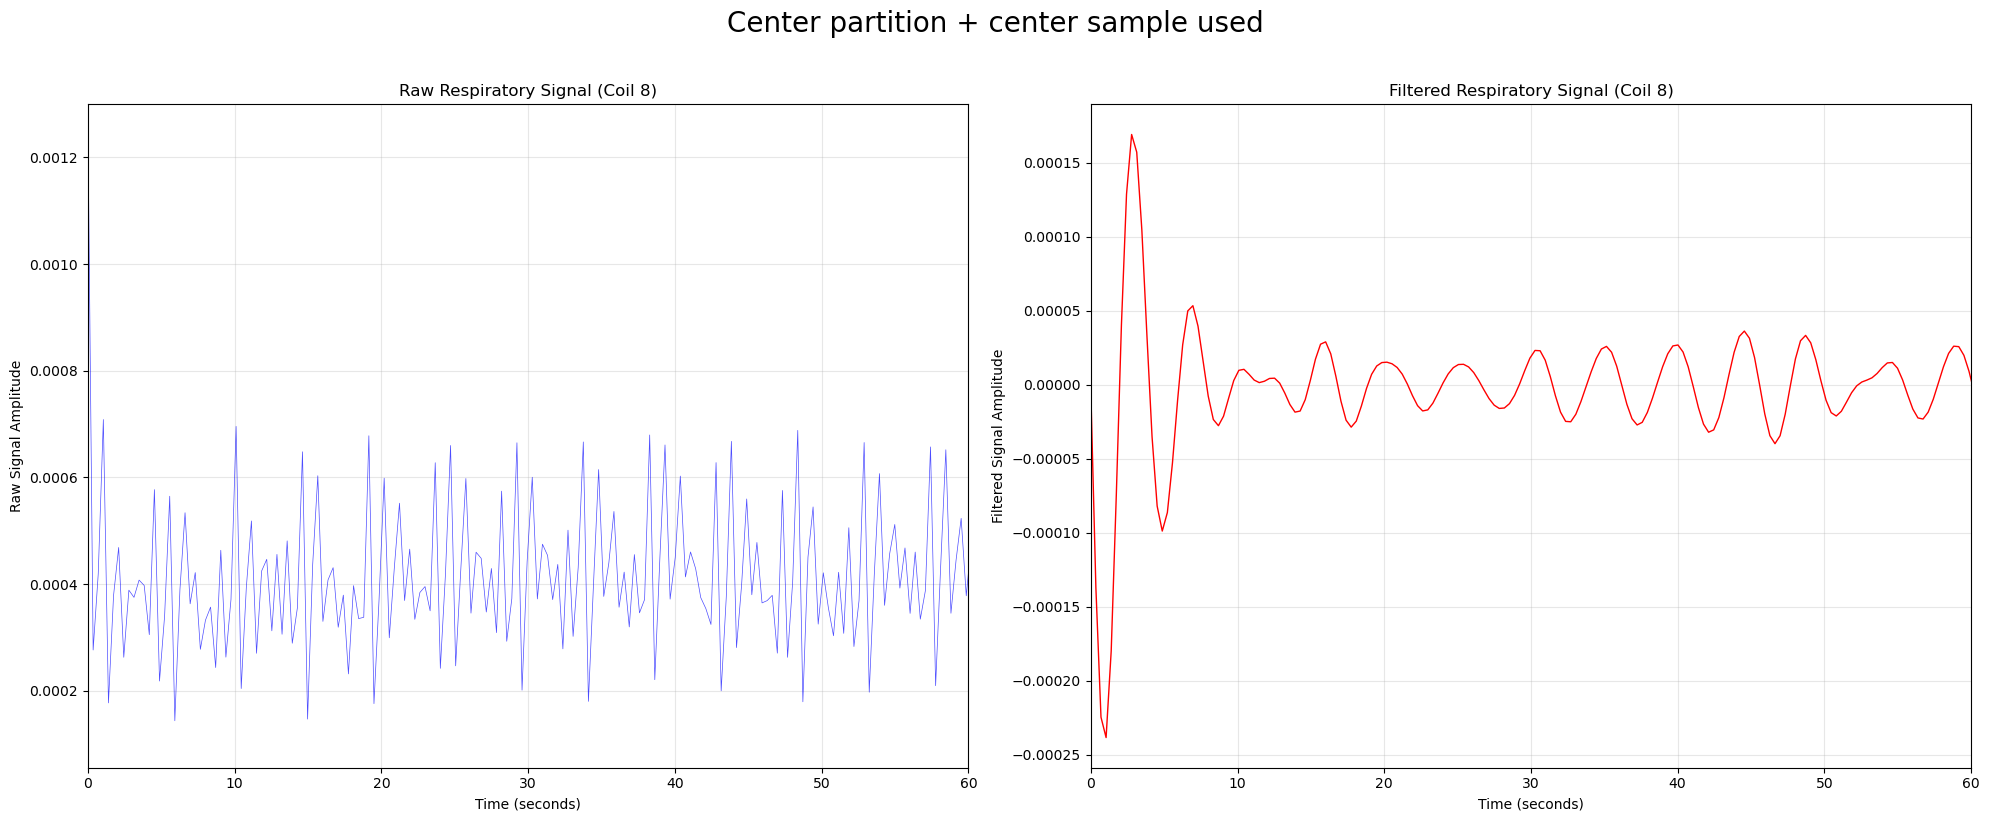

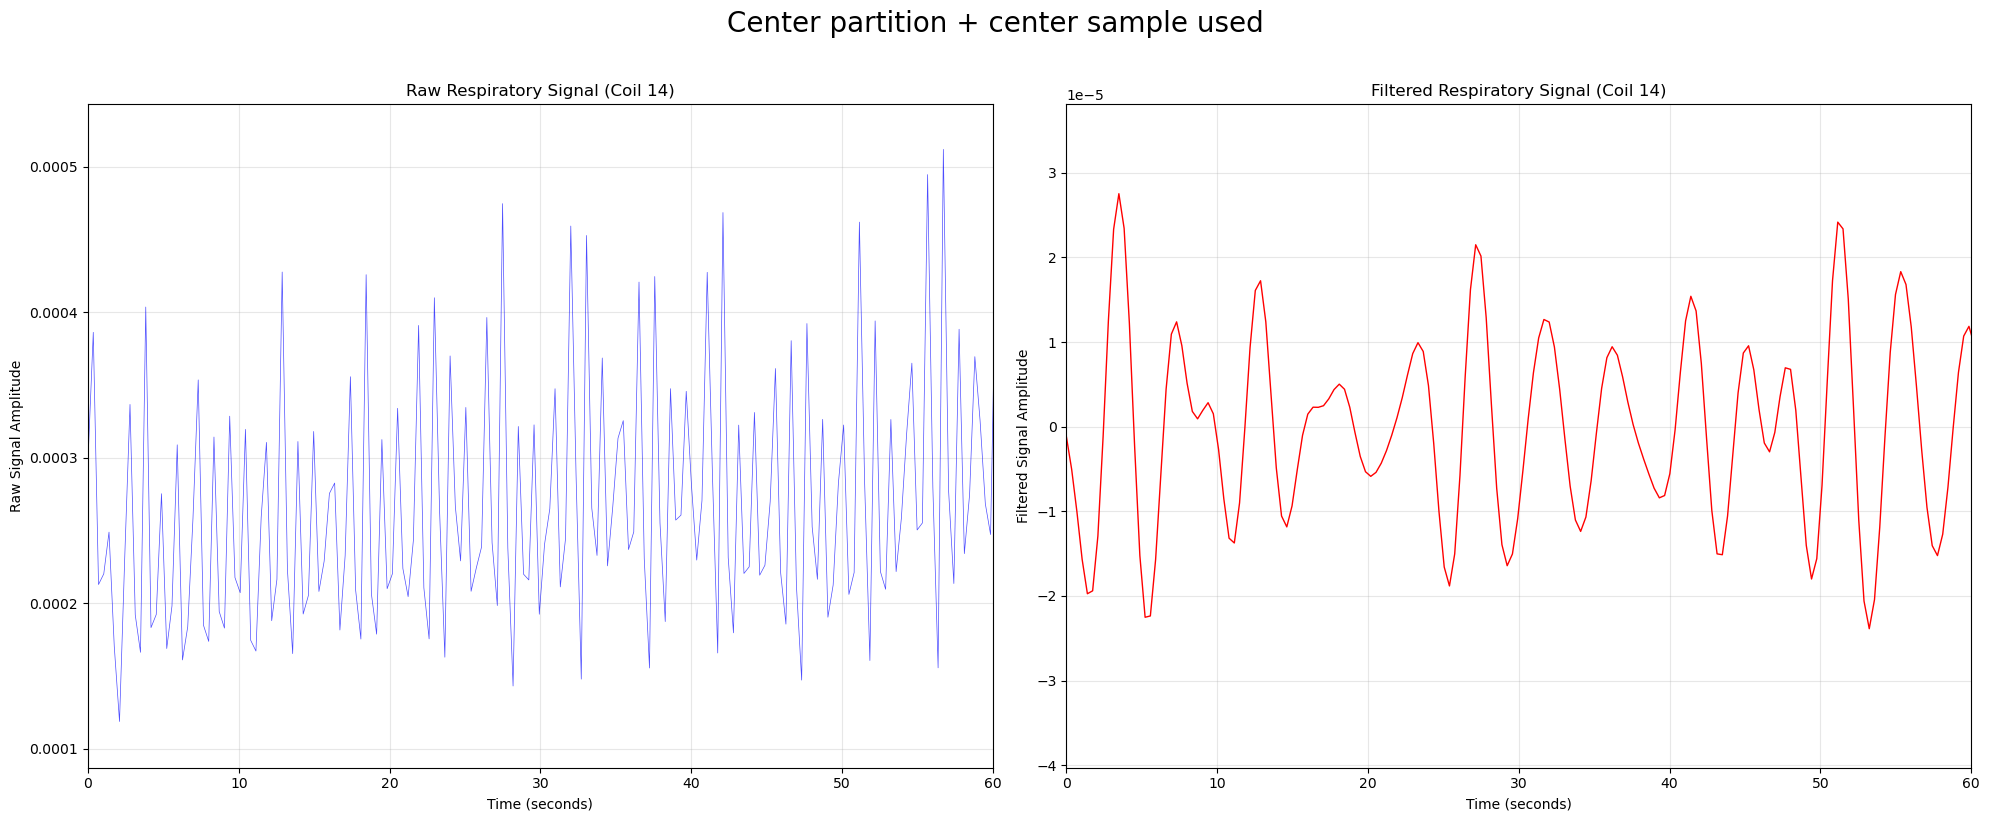

In [12]:
coil_indices = [0, 8, 14]

plot_raw_and_filtered_signal(raw_signal_center_sample, filt_center_sample, coil_indices, TR_eff, samples_to_discard=0, title_info="Center partition + center sample used")

### PCA

In [13]:
n_components = 3
resp_center_pca = pca_resp_signal(filt_center_sample, n_components=n_components)

Final respiratory signal shape: (2002,)
PCA explained variance ratio: 0.474


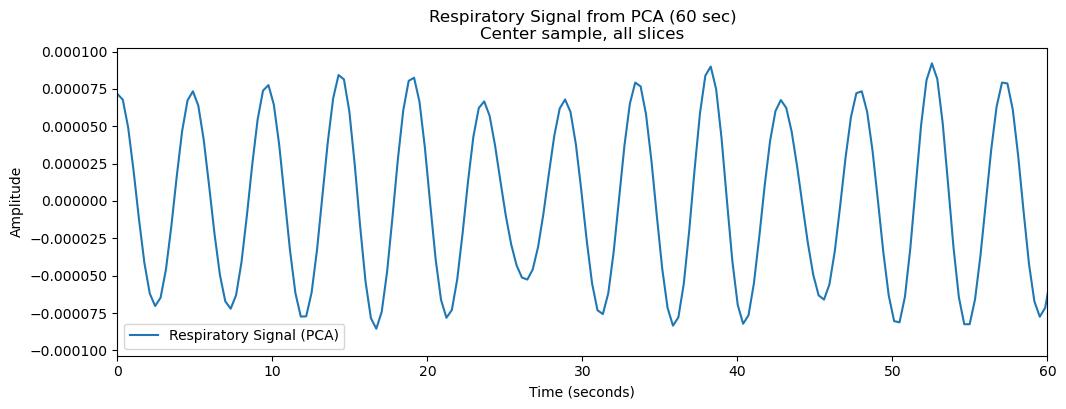

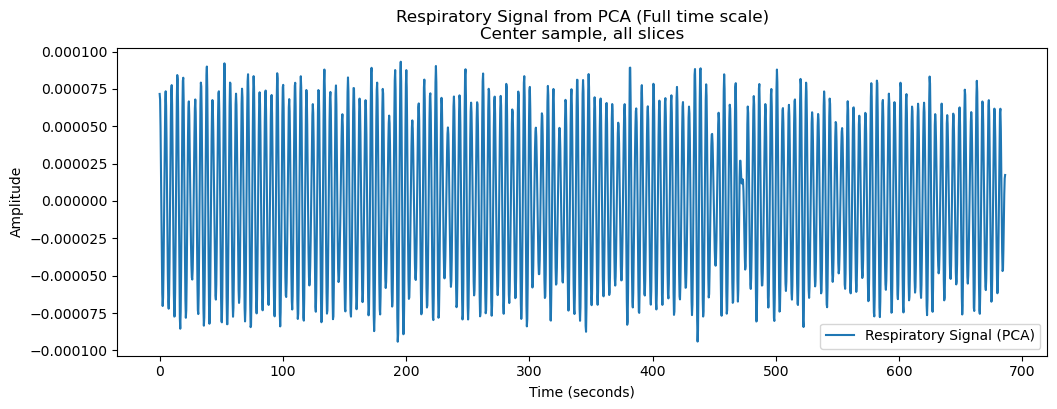

In [14]:
plot_resp_signal(resp_center_pca[30:], TR=TR_eff, title_info="Center sample, all slices")
plot_resp_signal(resp_center_pca[30:], TR=TR_eff, title_info="Center sample, all slices", xlim=False)

### Gating (Central partition)

In [15]:
num_gates = 5
img_shape = (ksp_512.shape[1], ksp_512.shape[3], ksp_512.shape[3])

## Amplitude based
idx, resp_trimmed, data_bins, spoke_bins, index_bins = gating_functions.gate_resp_signal_sparse(ksp_512, 
                                                                                               resp_center_pca,
                                                                                               num_gates=num_gates,
                                                                                               img_shape=img_shape,
                                                                                               spokes_to_discard=0,
                                                                                               gating_method='amplitude')


Gate 1: 401 spoke groups, 23258 total spokes
Gate 2: 400 spoke groups, 23200 total spokes
Gate 3: 400 spoke groups, 23200 total spokes
Gate 4: 400 spoke groups, 23200 total spokes
Gate 5: 401 spoke groups, 23258 total spokes
Gate 1: kspace shape = (15, 401, 58, 512), coords shape = (401, 58, 512, 3)
Gate 2: kspace shape = (15, 400, 58, 512), coords shape = (400, 58, 512, 3)
Gate 3: kspace shape = (15, 400, 58, 512), coords shape = (400, 58, 512, 3)
Gate 4: kspace shape = (15, 400, 58, 512), coords shape = (400, 58, 512, 3)
Gate 5: kspace shape = (15, 401, 58, 512), coords shape = (401, 58, 512, 3)


### Visualize gates with signal

Average signal across gates = [-6.713815901985202e-05, -3.9079269040674657e-05, -6.658532416727758e-07, 3.8586932635085025e-05, 6.829346041363e-05]


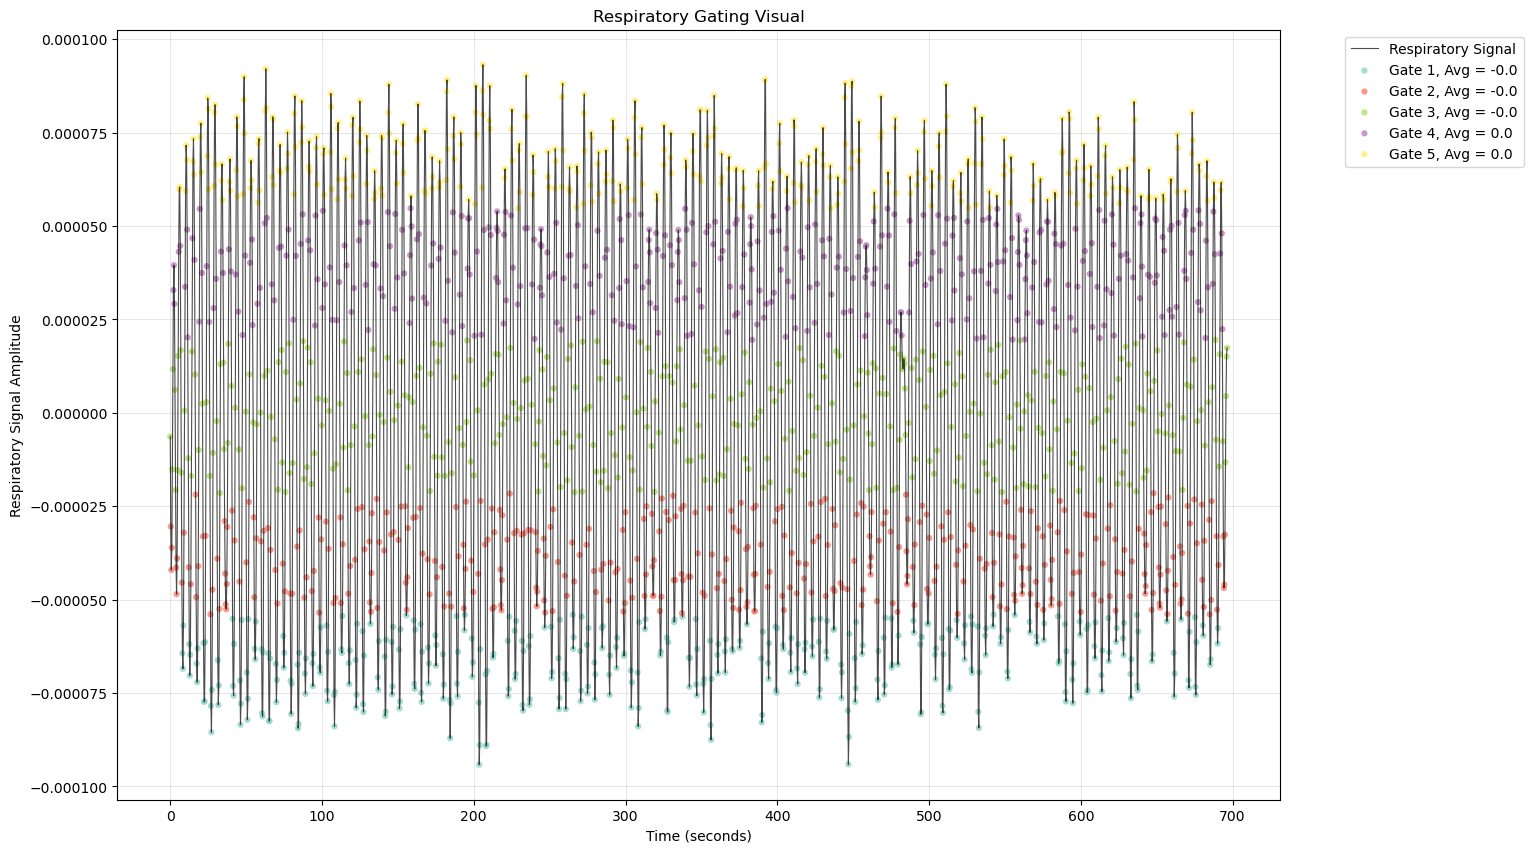

In [16]:
import gating_visuals

gating_visuals.visualize_resp_gating(resp_trimmed, idx, TR=TR_eff, num_gates=5)

### Plot k-space at each gate

In [17]:
def plot_ksp_data_gate(ksp_data, coil_idx, title=""):
    """" Plot ksp data with """

Original shape: (15, 401, 58, 512)
After transpose: (15, 58, 401, 512)
ncoils=15, nslices=58, nsamples=512, nspokes=401
ksp_data_flat.shape = (15, 58, 205312)
Data min: 9.878167173127395e-10
Data max: 0.0014221363235265017
Data mean: 8.952044481702615e-06
Data median: 2.778754151222529e-06
Data std: 3.4052944101858884e-05
Non-zero elements: 11908096 / 11908096


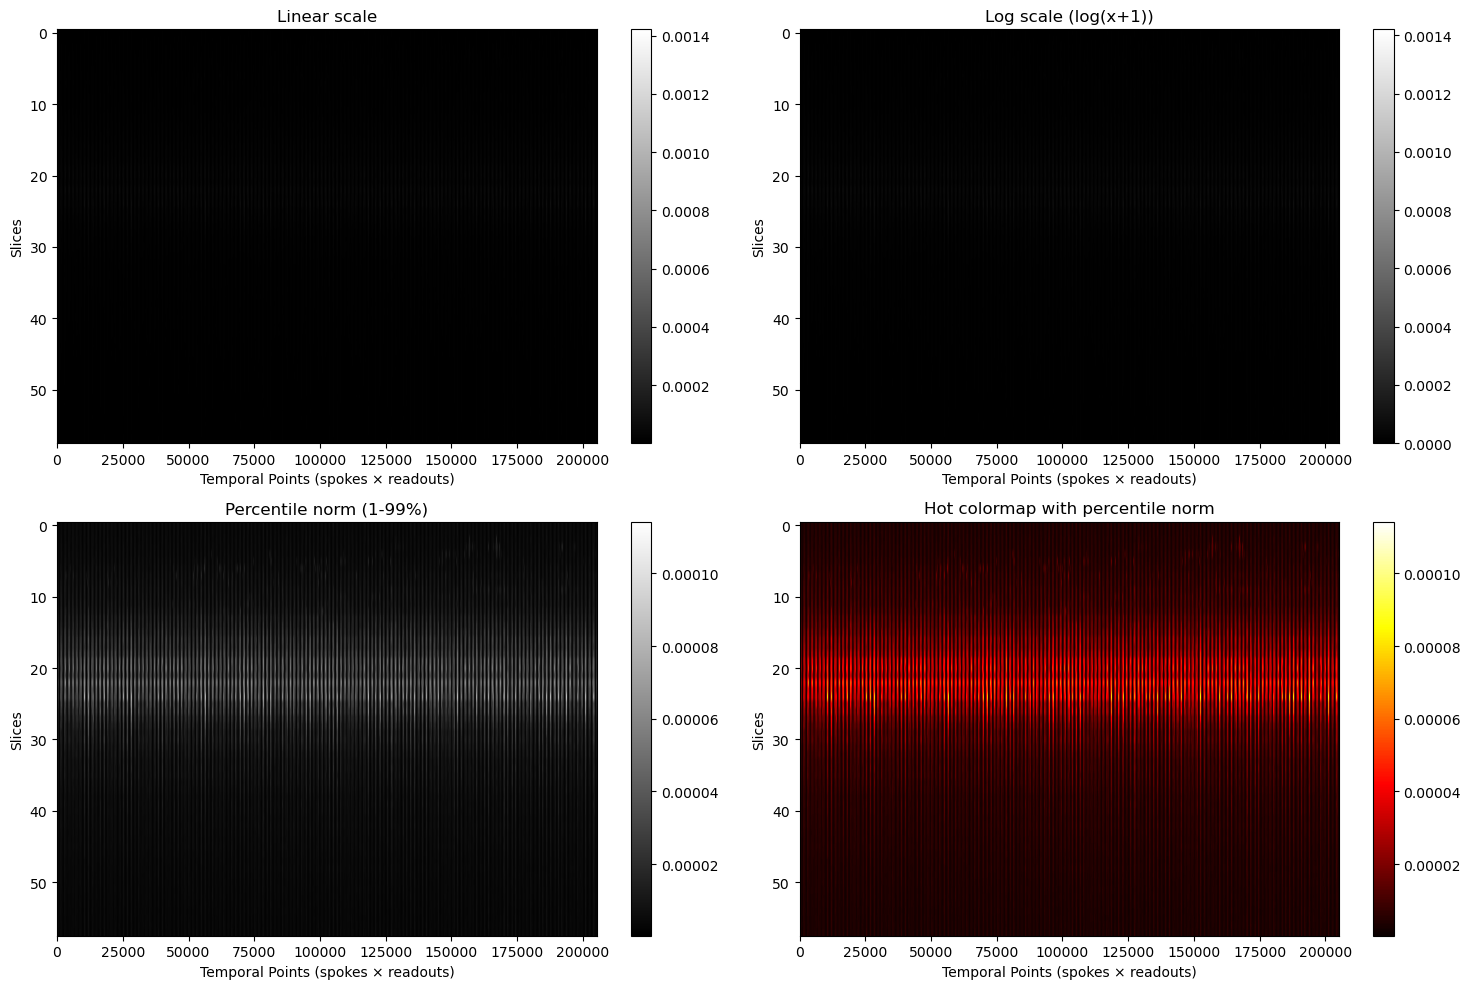

In [18]:
def plot_ksp_data_gate_debug(ksp_data, coil_idx, title=""):
    """Plot ksp data for slices vs (spoke,sample) dimension collapsed"""
    
    print(f"Original shape: {ksp_data.shape}")
    # Original: (ncoils, nspokes, nslices, nsamples)
    
    ksp_data = ksp_data.transpose(0, 2, 1, 3)
    print(f"After transpose: {ksp_data.shape}")
    
    ncoils, nslices, nspokes, nsamples = ksp_data.shape
    print(f"ncoils={ncoils}, nslices={nslices}, nsamples={nsamples}, nspokes={nspokes}")
    
    # Reshape to collapse spokes and samples into one temporal dimension
    ksp_data_flat = ksp_data.reshape(ncoils, nslices, -1)
    print(f"ksp_data_flat.shape = {ksp_data_flat.shape}")
    
    # Extract data for visualization
    plot_data = np.abs(ksp_data_flat[coil_idx, :, :])  # (nslices, temporal_pts)
    
    # DEBUGGING: Check data statistics
    print(f"Data min: {plot_data.min()}")
    print(f"Data max: {plot_data.max()}")
    print(f"Data mean: {plot_data.mean()}")
    print(f"Data median: {np.median(plot_data)}")
    print(f"Data std: {plot_data.std()}")
    print(f"Non-zero elements: {np.count_nonzero(plot_data)} / {plot_data.size}")
    
    # Try different visualizations to see what works
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Linear scale
    im1 = axes[0,0].imshow(plot_data, cmap='gray', aspect='auto')
    axes[0,0].set_title("Linear scale")
    plt.colorbar(im1, ax=axes[0,0])
    
    # Plot 2: Log scale
    im2 = axes[0,1].imshow(np.log(plot_data + 1), cmap='gray', aspect='auto')
    axes[0,1].set_title("Log scale (log(x+1))")
    plt.colorbar(im2, ax=axes[0,1])
    
    # Plot 3: Percentile-based normalization
    vmin, vmax = np.percentile(plot_data, [1, 99])
    im3 = axes[1,0].imshow(plot_data, cmap='gray', aspect='auto', 
                           vmin=vmin, vmax=vmax)
    axes[1,0].set_title(f"Percentile norm (1-99%)")
    plt.colorbar(im3, ax=axes[1,0])
    
    # Plot 4: Hot colormap (better for k-space)
    im4 = axes[1,1].imshow(plot_data, cmap='hot', aspect='auto',
                           vmin=vmin, vmax=vmax)
    axes[1,1].set_title("Hot colormap with percentile norm")
    plt.colorbar(im4, ax=axes[1,1])
    
    for ax in axes.flat:
        ax.set_xlabel("Temporal Points (spokes × readouts)")
        ax.set_ylabel("Slices")
    
    plt.tight_layout()
    plt.show()


plot_ksp_data_gate_debug(data_bins[0], coil_idx=8)

Average value, slices vs samples per gate = 1.6150210285559297e-05
Average value, readouts vs spokes per gate = 3.7186113331699744e-05
Average value, slices vs center sample per gate = 0.0001453267177566886


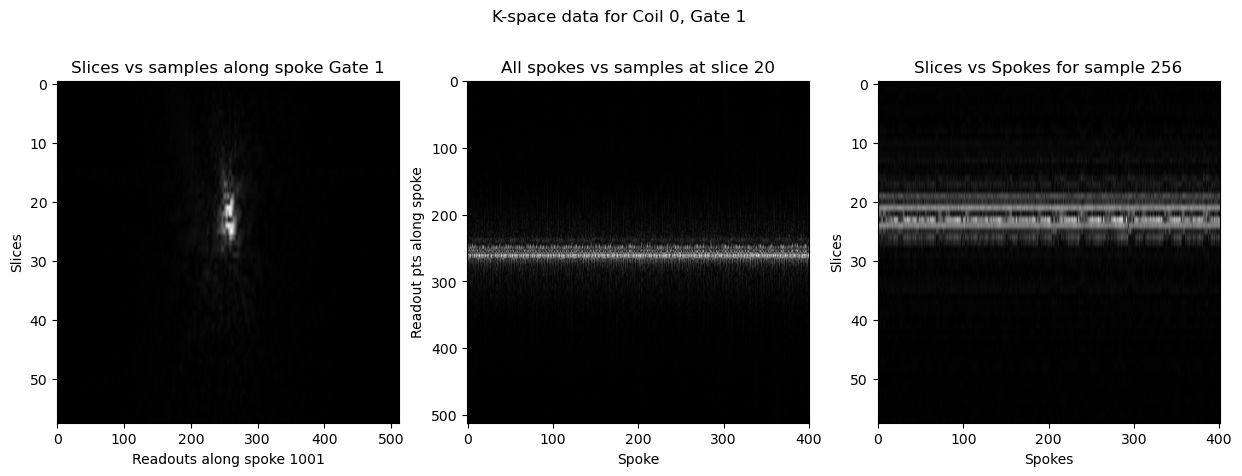

Average value, slices vs samples per gate = 2.4775070414762013e-05
Average value, readouts vs spokes per gate = 3.610012208810076e-05
Average value, slices vs center sample per gate = 0.00014387324335984886


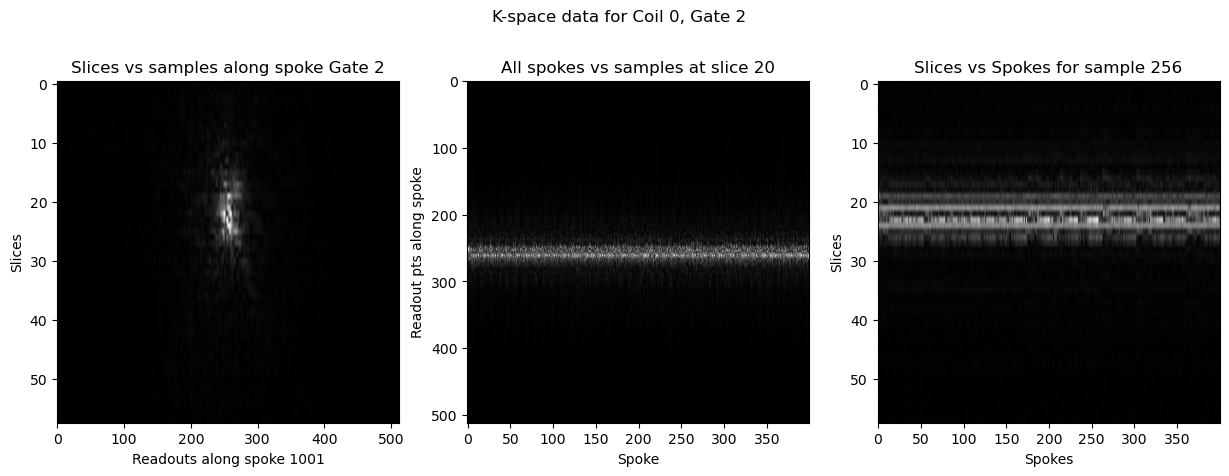

Average value, slices vs samples per gate = 3.577272582333535e-05
Average value, readouts vs spokes per gate = 3.518871744745411e-05
Average value, slices vs center sample per gate = 0.0001446293172193691


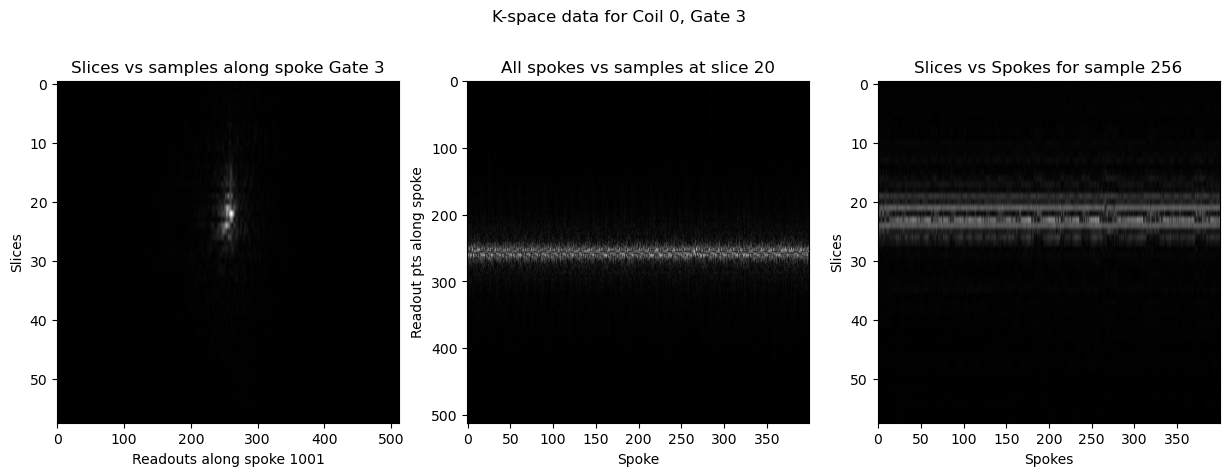

Average value, slices vs samples per gate = 1.5816338418517262e-05
Average value, readouts vs spokes per gate = 3.6506735341390595e-05
Average value, slices vs center sample per gate = 0.0001445500529371202


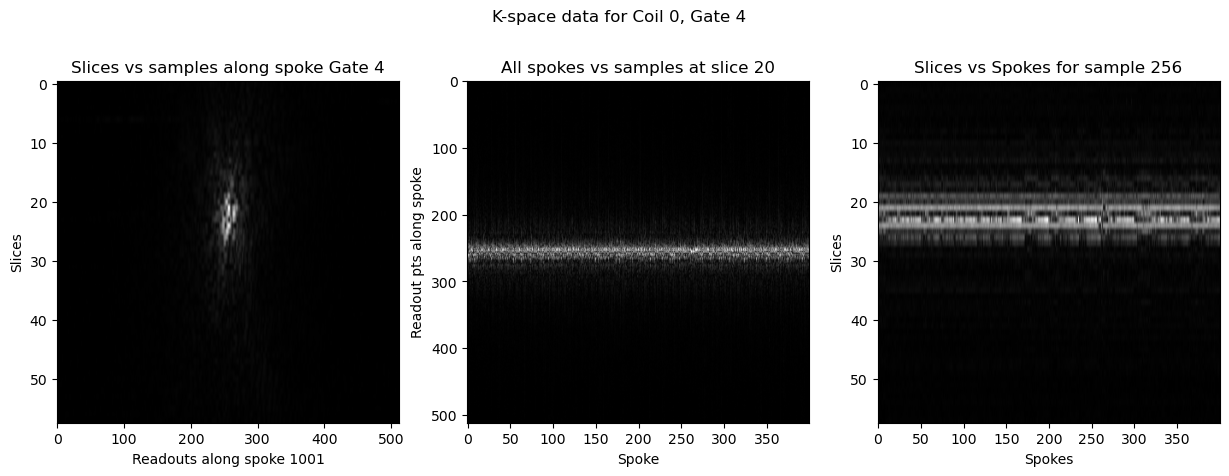

Average value, slices vs samples per gate = 1.830381188483443e-05
Average value, readouts vs spokes per gate = 3.7234160117805004e-05
Average value, slices vs center sample per gate = 0.00014397002814803272


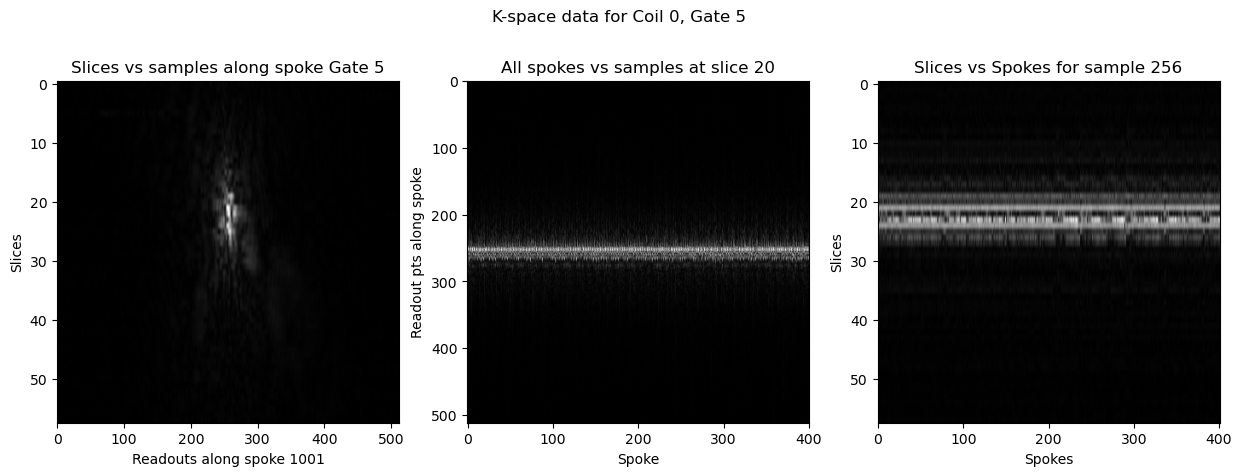

In [26]:
def plot_ksp_data_new(ksp_data, coil_idx, center_slice = None, spoke_idx =0, center_sample = None, title_info=""):

    ksp_data = ksp_data.transpose(0,2,1,3)
    ## Get all dims 
    ncoils, nslices, nspokes, nsamples= ksp_data.shape

    ## If center idx not given, assume it is middle
    if center_slice is None:
        center_slice = nslices // 2
    
    if center_sample is None:
        center_sample = nsamples //2

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    ## Plot spokes vs slices
    axs[0].imshow(np.abs(ksp_data[0, :, 0, :]), cmap='gray', aspect=nsamples/nslices)
    print(f'Average value, slices vs samples per gate = {np.mean(np.abs(ksp_data[0, :, 0, :]))}')
    axs[0].set_xlabel(f"Readouts along spoke {spoke_idx}")
    axs[0].set_ylabel("Slices")
    axs[0].set_title(f"Slices vs samples along spoke {title_info}")

    ## Plot spokes vs samples for center idx 
    axs[1].imshow(np.abs(ksp_data[0, center_slice, :, :]).T, cmap='gray', aspect=nspokes/nsamples)
    print(f'Average value, readouts vs spokes per gate = {np.mean(np.abs(ksp_data[0, center_slice, :, :]).T)}')
    axs[1].set_xlabel("Spoke")
    axs[1].set_ylabel("Readout pts along spoke")
    axs[1].set_title(f"All spokes vs samples at slice {center_slice}")

    ## Plot all slices vs center sample
    axs[2].imshow(np.abs(ksp_data[0, :, :, center_sample]), cmap='gray', aspect=nspokes/nslices)
    print(f'Average value, slices vs center sample per gate = {np.mean(np.abs(ksp_data[0, :, :, center_sample]))}')
    axs[2].set_xlabel("Spokes")
    axs[2].set_ylabel("Slices")
    axs[2].set_title(f"Slices vs Spokes for sample {center_sample}")
    
    fig.suptitle(f"K-space data for Coil {coil_idx}, {title_info}")

    plt.show()

for i in range(5):
    plot_ksp_data_new(data_bins[i], coil_idx=0, center_slice=20, spoke_idx=1001
                      , title_info=f"Gate {i+1}")

In [23]:
# from sigpy.mri import dcf

# def nufft_recon_all_gates(data_bins, spoke_bins, img_shape, gates_to_reconstruct):
#     gated_dcfs = []
#     gated_images = []
#     for gate in gates_to_reconstruct:
#         print(f'Processing gate {gate}.....')
#         kspace_gate = data_bins[gate]  # Shape: (coils, spokes, partitions, samples)
#         coords_gate = spoke_bins[gate]  # Shape: (spokes, partitions, samples, 3)
#         dcf_ksp = dcf.pipe_menon_dcf(coords_gate, img_shape)
#         img_grid = sp.nufft_adjoint(kspace_gate*dcf_ksp, coords_gate)

#         ## Save arrays
#         gated_dcfs.append(dcf_ksp)
#         gated_images.append(img_grid)

#     return gated_dcfs, gated_images


# #%%
# gated_dcf, gated_image = nufft_recon_all_gates(data_bins[0],
#                                             spoke_bins[0],
#                                             img_shape=(58, 512, 512),
#                                             gates_to_reconstruct=[0])



In [24]:
# print(gated_image[0].shape)

In [25]:
# import recon_plot_helpers

# gate_image = recon_plot_helpers.calculate_rss_image(gated_image[0])
# recon_plot_helpers.plot_recons_all_axes(gate_image[0], title=f"RSS Gate 0 - MID 0082 - 512 Readouts, amp gated")

### Save gates

In [26]:
def save_gate_outputs_pickle(file, idx, signal_trimmed, data_bins, spoke_bins, index_bins):
    '''Save outputs of gate_resp_signal as compressed npz file
    
    file : file, str, or Pathlib.path
        Either filename (string) or open file (path object) where data should be saved. .npz appended if not already there
    idx : ndarray
        1D array containing gate indices
    signal_trimmed : ndarray
        1D array containing resp signal used for gating
    data_bins : list
        List of ndarrays, each element is gated k-space array
    spoke_bins : list
        List of ndarrays, each element is gated GA coords
    index_bins : list
        List of ndarrays, each element is list of indices for that gate
    
    '''
    data = {
        "idx": idx,
        "signal_trimmed": signal_trimmed,
        "data_bins": data_bins,
        "spoke_bins": spoke_bins,
        "index_bins": index_bins,
    }
    with open(f"{file}.pkl", "wb") as f:
        pickle.dump(data, f)

    print(f'File successfully saved as {file}')

In [27]:
save_gate_outputs_pickle('gates_sparse_amp_center_samp_512', idx, resp_trimmed, data_bins, spoke_bins, index_bins)

File successfully saved as gates_sparse_amp_center_samp_512


In [28]:
# save_gate_outputs_pickle('gates_amp_cent_slice', idx_amp_cent, resp_trimmed_amp_cent, data_bins_amp_cent, spoke_bins_amp_cent, index_bins_amp_cent)
# save_gate_outputs_pickle('gates_phase_cent_slice', idx_phase_cent, resp_trimmed_phase_cent, data_bins_phase_cent, spoke_bins_phase_cent, index_bins_phase_cent)

##